In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import kagglehub

print("works")

works


# Importing all the libraries 

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
from torchvision.models import DenseNet121_Weights

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# Data Loading & Preprocessing 

In [3]:
# Define metadata as the metdat.csv
metadata = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# Include a path column in the dataset 
def get_path(image_id):
    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        path = f'/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/{folder}/{image_id}.jpg'
        if os.path.exists(path):
            return path
    return None

metadata['path'] = metadata['image_id'].apply(get_path)

# Encode all dieases in the label col 
label_map = {'akiec':0,'bcc':1,'bkl':2,'df':3,'mel':4,'nv':5,'vasc':6}
metadata['label'] = metadata['dx'].map(label_map)

print(metadata.shape)
print(metadata.head())

(10015, 9)
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                                path  label  
0  /kaggle/input/datasets/kmader/skin-cancer-mnis...      2  
1  /kaggle/input/datasets/kmader/skin-cancer-mnis...      2  
2  /kaggle/input/datasets/kmader/skin-cancer-mnis...      2  
3  /kaggle/input/datasets/kmader/skin-cancer-mnis...      2  
4  /kaggle/input/datasets/kmader/skin-cancer-mnis...      2  


In [6]:
#lesion-level train/valid split

unique_lesions = metadata['lesion_id'].unique()
train_lesions, valid_lesions = train_test_split(unique_lesions, test_size=0.2, random_state=42)

train_df = metadata[metadata['lesion_id'].isin(train_lesions)].copy()
valid_df = metadata[metadata['lesion_id'].isin(valid_lesions)].copy()

print(train_df['dx'].value_counts())
print(valid_df['dx'].value_counts())

dx
nv       5403
mel       888
bkl       855
bcc       382
akiec     259
vasc      106
df         81
Name: count, dtype: int64
dx
nv       1302
bkl       244
mel       225
bcc       132
akiec      68
vasc       36
df         34
Name: count, dtype: int64


In [8]:
# There's so much data imbalance First lemme fix that

In [7]:
# undersample nv
target_nv = 900
nv_df = train_df[train_df['dx'] == 'nv'].sample(n=target_nv, random_state=42)
other_df = train_df[train_df['dx'] != 'nv']
train_df_balanced = pd.concat([nv_df, other_df])

print(train_df_balanced['dx'].value_counts())

# oversample rare classes
def oversample_class(df, dx_class, target_count):
    class_df = df[df['dx'] == dx_class]
    n_needed = target_count - len(class_df)
    if n_needed <= 0:
        return df
    extra = class_df.sample(n=n_needed, replace=True, random_state=42)
    return pd.concat([df, extra])

train_df_balanced2 = train_df_balanced.copy()
for cls, target in [('df', 400), ('vasc', 400), ('akiec', 500), ('bcc', 600)]:
    train_df_balanced2 = oversample_class(train_df_balanced2, cls, target)

train_df_balanced2 = train_df_balanced2.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df_balanced2['dx'].value_counts())

dx
nv       900
mel      888
bkl      855
bcc      382
akiec    259
vasc     106
df        81
Name: count, dtype: int64
dx
nv       900
mel      888
bkl      855
bcc      600
akiec    500
df       400
vasc     400
Name: count, dtype: int64


In [8]:
# Define all transforms 

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    normalize,
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = row["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:


train_dataset = SkinCancerDataset(train_df_balanced2, transform=train_transform)
valid_dataset = SkinCancerDataset(valid_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print(len(train_loader), len(valid_loader))

142 64


# Efficient Net model


In [12]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader):.4f}, Train Acc {train_acc:.4f}")

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader)
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader):.4f}, Val Acc {val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


Epoch 1: Train Loss 1.2858, Train Acc 0.5556
  → saved new best model
Val Loss 0.7849, Val Acc 0.7104
Epoch 2: Train Loss 0.6275, Train Acc 0.7711
  → saved new best model
Val Loss 0.7615, Val Acc 0.7070
Epoch 3: Train Loss 0.4633, Train Acc 0.8340
  → saved new best model
Val Loss 0.6407, Val Acc 0.7599
Epoch 4: Train Loss 0.3547, Train Acc 0.8734
  → saved new best model
Val Loss 0.6125, Val Acc 0.7800
Epoch 5: Train Loss 0.2896, Train Acc 0.8921
  → saved new best model
Val Loss 0.5970, Val Acc 0.7849
Epoch 6: Train Loss 0.2238, Train Acc 0.9269
  → saved new best model
Val Loss 0.5820, Val Acc 0.8045
Epoch 7: Train Loss 0.1879, Train Acc 0.9355
  → saved new best model
Val Loss 0.5757, Val Acc 0.8065
Epoch 8: Train Loss 0.1534, Train Acc 0.9509
Val Loss 0.7103, Val Acc 0.7732
Epoch 9: Train Loss 0.1385, Train Acc 0.9536
Val Loss 0.7231, Val Acc 0.7829
Epoch 10: Train Loss 0.1191, Train Acc 0.9593
Val Loss 0.7647, Val Acc 0.7589
Epoch 11: Train Loss 0.0942, Train Acc 0.9683
Val Loss

In [13]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# Dense Net 121

In [ ]:
model2 = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model2.classifier = nn.Linear(model2.classifier.in_features, 7)
model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 124MB/s] 


In [16]:


for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader):.4f}, Train Acc {train_acc:.4f}")

    model2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader)
        torch.save(model2.state_dict(), 'best_model_densenet.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader):.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 0.2068, Train Acc 0.9282
Val Loss 0.7352, Val Acc 0.7550
Epoch 2: Train Loss 0.1571, Train Acc 0.9465
Val Loss 0.6305, Val Acc 0.7908
Epoch 3: Train Loss 0.1269, Train Acc 0.9617
Val Loss 0.7198, Val Acc 0.7829
Epoch 4: Train Loss 0.1271, Train Acc 0.9575
Val Loss 0.9482, Val Acc 0.7202
Epoch 5: Train Loss 0.1065, Train Acc 0.9661
Val Loss 0.6441, Val Acc 0.8040
Epoch 6: Train Loss 0.0805, Train Acc 0.9731
Val Loss 0.7261, Val Acc 0.7937
Epoch 7: Train Loss 0.0749, Train Acc 0.9751
Val Loss 0.7969, Val Acc 0.7727
Epoch 8: Train Loss 0.0692, Train Acc 0.9797
Val Loss 0.6977, Val Acc 0.7972
Epoch 9: Train Loss 0.0631, Train Acc 0.9797
Val Loss 0.8053, Val Acc 0.7820
Epoch 10: Train Loss 0.0587, Train Acc 0.9839
Val Loss 0.8702, Val Acc 0.7795
Epoch 11: Train Loss 0.0544, Train Acc 0.9822
Val Loss 0.8903, Val Acc 0.7599
Epoch 12: Train Loss 0.0468, Train Acc 0.9848
Val Loss 0.8208, Val Acc 0.7942
Epoch 13: Train Loss 0.0603, Train Acc 0.9802
Val Loss 0.7751, Val Acc 0.

In [17]:
# Ensemble evaluation

model.load_state_dict(torch.load('best_model.pth'))
model2.load_state_dict(torch.load('best_model_densenet.pth'))

model.eval()
model2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        
        outputs1 = torch.softmax(model(images), dim=1)
        outputs2 = torch.softmax(model2(images), dim=1)
        
        avg_outputs = (outputs1 + outputs2) / 2
        _, predicted = torch.max(avg_outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.60      0.56      0.58        68
         bcc       0.75      0.86      0.80       132
         bkl       0.67      0.81      0.73       244
          df       0.77      0.50      0.61        34
         mel       0.56      0.71      0.62       225
          nv       0.94      0.86      0.90      1302
        vasc       0.80      0.89      0.84        36

    accuracy                           0.82      2041
   macro avg       0.73      0.74      0.73      2041
weighted avg       0.84      0.82      0.83      2041



# GWD 

In [19]:
from IPython.display import FileLink


FileLink('best_model_densenet.pth')

/kaggle/working/best_model_densenet.pth

In [20]:
FileLink('best_model.pth')

/kaggle/working/best_model.pth

In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]

        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (np.max(heatmap) + 1e-8)

        return heatmap, class_idx

In [22]:
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)
model.eval()

target_layer = model.features[-1]
print(target_layer)  # should show a Conv2d/BatchNorm block

Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


In [23]:
def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    superimposed = heatmap_color * alpha + img
    return np.uint8(superimposed)

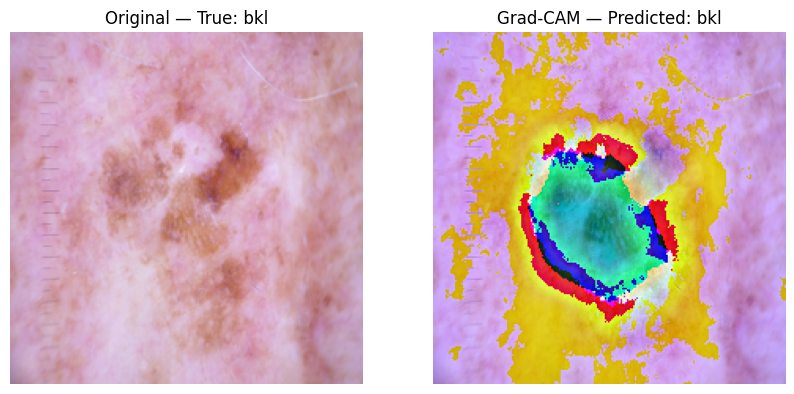

In [24]:
idx_to_class = {v: k for k, v in full_label_map.items()}

sample_row = valid_df.iloc[0]
img_path = sample_row['path']
true_label = sample_row['dx']

image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)
input_tensor.requires_grad_()

gradcam = GradCAM(model, target_layer)
heatmap, pred_class_idx = gradcam.generate(input_tensor)
pred_class = idx_to_class[pred_class_idx]

result = overlay_heatmap(img_path, heatmap)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(Image.open(img_path).resize((224,224)))
plt.title(f"Original — True: {true_label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Grad-CAM — Predicted: {pred_class}")
plt.axis('off')
plt.show()

# Hierarchical approach


In [ ]:
confused_cluster = ['nv', 'mel', 'bkl']

train_df_balanced2['stage1_label'] = train_df_balanced2['dx'].apply(lambda x: 1 if x in confused_cluster else 0)
valid_df['stage1_label'] = valid_df['dx'].apply(lambda x: 1 if x in confused_cluster else 0)

print(train_df_balanced2['stage1_label'].value_counts())
print(valid_df['stage1_label'].value_counts())

In [ ]:
stage1_train_df = train_df_balanced2.copy()
stage1_valid_df = valid_df.copy()

stage1_train_df = stage1_train_df.drop(columns=['label']).rename(columns={'stage1_label': 'label'})
stage1_valid_df = stage1_valid_df.drop(columns=['label']).rename(columns={'stage1_label': 'label'})

print(stage1_train_df[['dx','label']].drop_duplicates())

In [ ]:
stage1_train_dataset = SkinCancerDataset(stage1_train_df, transform=train_transform)
stage1_valid_dataset = SkinCancerDataset(stage1_valid_df, transform=val_transform)

stage1_train_loader = DataLoader(stage1_train_dataset, batch_size=32, shuffle=True)
stage1_valid_loader = DataLoader(stage1_valid_dataset, batch_size=32, shuffle=False)

model_stage1 = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage1.classifier[1] = nn.Linear(model_stage1.classifier[1].in_features, 2)
model_stage1 = model_stage1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_stage1.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

In [ ]:

for epoch in range(num_epochs):
    model_stage1.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in stage1_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_stage1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(stage1_train_loader):.4f}, Train Acc {train_acc:.4f}")

    model_stage1.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in stage1_valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage1(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(stage1_valid_loader) < best_val_loss:
        best_val_loss = val_loss/len(stage1_valid_loader)
        torch.save(model_stage1.state_dict(), 'stage1v1.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(stage1_valid_loader):.4f}, Val Acc {val_acc:.4f}")

In [ ]:
train_df_balanced2.to_csv('/kaggle/working/train_df_balanced2.csv', index=False)
valid_df.to_csv('/kaggle/working/valid_df.csv', index=False)

In [ ]:
torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
torch.save(model2.state_dict(), '/kaggle/working/best_model_densenet.pth')
torch.save(model_stage1.state_dict(), '/kaggle/working/best_model_stage1.pth')

In [ ]:
other_cluster = ['akiec', 'bcc', 'df', 'vasc']

stage2b_train_df = train_df_balanced2[train_df_balanced2['dx'].isin(other_cluster)].copy()
stage2b_valid_df = valid_df[valid_df['dx'].isin(other_cluster)].copy()

stage2b_label_map = {'akiec': 0, 'bcc': 1, 'df': 2, 'vasc': 3}

stage2b_train_df = stage2b_train_df.drop(columns=['label'])
stage2b_valid_df = stage2b_valid_df.drop(columns=['label'])
stage2b_train_df['label'] = stage2b_train_df['dx'].map(stage2b_label_map)
stage2b_valid_df['label'] = stage2b_valid_df['dx'].map(stage2b_label_map)

print(stage2b_train_df['dx'].value_counts())
print(stage2b_valid_df['dx'].value_counts())

stage2b_train_dataset = SkinCancerDataset(stage2b_train_df, transform=train_transform)
stage2b_valid_dataset = SkinCancerDataset(stage2b_valid_df, transform=val_transform)

stage2b_train_loader = DataLoader(stage2b_train_dataset, batch_size=32, shuffle=True)
stage2b_valid_loader = DataLoader(stage2b_valid_dataset, batch_size=32, shuffle=False)

model_stage2b = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage2b.classifier[1] = nn.Linear(model_stage2b.classifier[1].in_features, 4)
model_stage2b = model_stage2b.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_stage2b.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')


In [ ]:
# reload dataframes
train_df_balanced2 = pd.read_csv('/kaggle/working/train_df_balanced2.csv')
valid_df = pd.read_csv('/kaggle/working/valid_df.csv')

# rebuild datasets/loaders (fast, no training)
train_dataset = SkinCancerDataset(train_df_balanced2, transform=train_transform)
valid_dataset = SkinCancerDataset(valid_df, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# rebuild model architecture, then load saved weights
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model = model.to(device)

In [ ]:

for epoch in range(num_epochs):
    model_stage2b.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in stage2b_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_stage2b(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(stage2b_train_loader):.4f}, Train Acc {train_acc:.4f}")

    model_stage2b.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in stage2b_valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage2b(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(stage2b_valid_loader) < best_val_loss:
        best_val_loss = val_loss/len(stage2b_valid_loader)
        torch.save(model_stage2b.state_dict(), 'stage2a.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(stage2b_valid_loader):.4f}, Val Acc {val_acc:.4f}")

In [ ]:
stage2a_train_df = train_df_balanced2[train_df_balanced2['dx'].isin(confused_cluster)].copy()
stage2a_valid_df = valid_df[valid_df['dx'].isin(confused_cluster)].copy()

stage2_label_map = {'bkl': 0, 'mel': 1, 'nv': 2}

stage2a_train_df = stage2a_train_df.drop(columns=['label'])
stage2a_valid_df = stage2a_valid_df.drop(columns=['label'])
stage2a_train_df['label'] = stage2a_train_df['dx'].map(stage2_label_map)
stage2a_valid_df['label'] = stage2a_valid_df['dx'].map(stage2_label_map)

stage2a_train_dataset = SkinCancerDataset(stage2a_train_df, transform=train_transform)
stage2a_valid_dataset = SkinCancerDataset(stage2a_valid_df, transform=val_transform)

stage2a_train_loader = DataLoader(stage2a_train_dataset, batch_size=32, shuffle=True)
stage2a_valid_loader = DataLoader(stage2a_valid_dataset, batch_size=32, shuffle=False)

model_stage2a = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage2a.classifier[1] = nn.Linear(model_stage2a.classifier[1].in_features, 3)
model_stage2a = model_stage2a.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_stage2a.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model_stage2a.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in stage2a_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_stage2a(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(stage2a_train_loader):.4f}, Train Acc {train_acc:.4f}")

    model_stage2a.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in stage2a_valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage2a(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(stage2a_valid_loader) < best_val_loss:
        best_val_loss = val_loss/len(stage2a_valid_loader)
        torch.save(model_stage2a.state_dict(), 'stage2b.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(stage2a_valid_loader):.4f}, Val Acc {val_acc:.4f}")

In [ ]:
# stage2a.pth is ACTUALLY your 4-class (akiec/bcc/df/vasc) model
model_stage2b.load_state_dict(torch.load('stage2a.pth'))

# stage2b.pth is ACTUALLY your 3-class (bkl/mel/nv) model
model_stage2a.load_state_dict(torch.load('stage2b.pth'))

model_stage1.load_state_dict(torch.load('stage1v1.pth'))

In [ ]:
sd = torch.load('stage2a.pth')
for k in sd:
    if 'classifier' in k:
        print('stage2a.pth ->', k, sd[k].shape)  # should show 4, not 3

sd = torch.load('stage2b.pth')
for k in sd:
    if 'classifier' in k:
        print('stage2b.pth ->', k, sd[k].shape)  # should show 3, not 4

In [17]:
model_stage1 = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage1.classifier[1] = nn.Linear(model_stage1.classifier[1].in_features, 2)
model_stage1.load_state_dict(torch.load('stage1v1.pth'))
model_stage1 = model_stage1.to(device)
model_stage1.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in stage1_valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage1(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
print(f"Stage1 isolated check: {correct/total:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


FileNotFoundError: [Errno 2] No such file or directory: 'stage1v1.pth'

In [ ]:
stage2a_to_7class = {0: 'bkl', 1: 'mel', 2: 'nv'}
stage2b_to_7class = {0: 'akiec', 1: 'bcc', 2: 'df', 3: 'vasc'}
full_label_map = {'akiec':0,'bcc':1,'bkl':2,'df':3,'mel':4,'nv':5,'vasc':6}

# correct loading given your filename mix-up
model_stage1 = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage1.classifier[1] = nn.Linear(model_stage1.classifier[1].in_features, 2)
model_stage1.load_state_dict(torch.load('stage1v1.pth'))
model_stage1 = model_stage1.to(device).eval()

model_stage2a = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage2a.classifier[1] = nn.Linear(model_stage2a.classifier[1].in_features, 3)
model_stage2a.load_state_dict(torch.load('stage2b.pth'))  # stage2b.pth is actually the 3-class one
model_stage2a = model_stage2a.to(device).eval()

model_stage2b = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_stage2b.classifier[1] = nn.Linear(model_stage2b.classifier[1].in_features, 4)
model_stage2b.load_state_dict(torch.load('stage2a.pth'))  # stage2a.pth is actually the 4-class one
model_stage2b = model_stage2b.to(device).eval()

all_preds = []
all_labels = []

full_valid_dataset = SkinCancerDataset(valid_df, transform=val_transform)
full_valid_loader = DataLoader(full_valid_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for images, labels in full_valid_loader:
        images = images.to(device)
        s1_out = model_stage1(images)
        s1_preds = torch.argmax(s1_out, dim=1)

        batch_final_preds = []
        for i in range(images.size(0)):
            img = images[i].unsqueeze(0)
            if s1_preds[i].item() == 1:
                s2_out = model_stage2a(img)
                s2_pred = torch.argmax(s2_out, dim=1).item()
                final_class = stage2a_to_7class[s2_pred]
            else:
                s2_out = model_stage2b(img)
                s2_pred = torch.argmax(s2_out, dim=1).item()
                final_class = stage2b_to_7class[s2_pred]
            batch_final_preds.append(full_label_map[final_class])

        all_preds.extend(batch_final_preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

In [ ]:
from IPython.display import FileLink

FileLink('best_model.pth')
FileLink('best_model_densenet.pth')

# Sticking on to Old Ensemble Learning

In [10]:
train_transform_v2 = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    normalize,
])

val_transform_v2 = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    normalize,
])

In [13]:
train_dataset_v2 = SkinCancerDataset(train_df_balanced2, transform=train_transform_v2)
valid_dataset_v2 = SkinCancerDataset(valid_df, transform=val_transform_v2)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=16, shuffle=True)   # smaller batch — 300x300 uses more GPU memory
valid_loader_v2 = DataLoader(valid_dataset_v2, batch_size=16, shuffle=False)

In [14]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

model_b3 = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
model_b3.classifier[1] = nn.Linear(model_b3.classifier[1].in_features, 7)
model_b3 = model_b3.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 163MB/s] 


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_b3.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model_b3.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_v2:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_b3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader_v2):.4f}, Train Acc {train_acc:.4f}")

    model_b3.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader_v2:
            images, labels = images.to(device), labels.to(device)
            outputs = model_b3(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader_v2) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader_v2)
        torch.save(model_b3.state_dict(), 'best_model_b3.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader_v2):.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 1.1445, Train Acc 0.5926
  → saved new best model
Val Loss 0.7168, Val Acc 0.7065
Epoch 2: Train Loss 0.5621, Train Acc 0.7966
  → saved new best model
Val Loss 0.6550, Val Acc 0.7374
Epoch 3: Train Loss 0.3974, Train Acc 0.8626
  → saved new best model
Val Loss 0.6285, Val Acc 0.7780
Epoch 4: Train Loss 0.2974, Train Acc 0.8930
  → saved new best model
Val Loss 0.5539, Val Acc 0.8045
Epoch 5: Train Loss 0.2301, Train Acc 0.9210
Val Loss 0.5735, Val Acc 0.8035
Epoch 6: Train Loss 0.1796, Train Acc 0.9357
Val Loss 0.6287, Val Acc 0.7844
Epoch 7: Train Loss 0.1547, Train Acc 0.9474
Val Loss 0.6596, Val Acc 0.7898
Epoch 8: Train Loss 0.1267, Train Acc 0.9555
Val Loss 0.7071, Val Acc 0.7854
Epoch 9: Train Loss 0.1052, Train Acc 0.9661
Val Loss 0.6060, Val Acc 0.8226
Epoch 10: Train Loss 0.0824, Train Acc 0.9729
Val Loss 0.6345, Val Acc 0.8217
Epoch 11: Train Loss 0.0673, Train Acc 0.9771
Val Loss 0.7829, Val Acc 0.7981
Epoch 12: Train Loss 0.0782, Train Acc 0.9727
Val L

In [20]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model.pth', map_location=device))
model = model.to(device).eval()

model2 = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model2.classifier = nn.Linear(model2.classifier.in_features, 7)
model2.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model_densenet.pth', map_location=device))
model2 = model2.to(device).eval()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 170MB/s]


In [21]:
model.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model.pth', map_location=device))
model2.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model_densenet.pth', map_location=device))

model = model.to(device).eval()
model2 = model2.to(device).eval() 

In [25]:
import torch.nn.functional as F

def tta_predict(model, image_tensor, n_variants=4):
    """Returns averaged softmax probs across TTA variants for one model."""
    variants = [image_tensor]  # original
    variants.append(torch.flip(image_tensor, dims=[3]))  # horizontal flip
    variants.append(torch.rot90(image_tensor, k=1, dims=[2, 3]))  # rotate 90
    variants.append(torch.rot90(image_tensor, k=3, dims=[2, 3]))  # rotate -90 (270)

    variants = variants[:n_variants]

    probs_sum = None
    for v in variants:
        with torch.no_grad():
            out = torch.softmax(model(v), dim=1)
        probs_sum = out if probs_sum is None else probs_sum + out

    return probs_sum / len(variants)


all_preds = []
all_labels = []

with torch.no_grad():
    for (images_224, labels), (images_300, _) in zip(valid_loader_224, valid_loader_300):
        images_224 = images_224.to(device)  
        images_300 = images_300.to(device)

        out1 = tta_predict(model, images_224)
        out2 = tta_predict(model2, images_224)
        out3 = tta_predict(model_b3, images_300)

        avg_outputs = (out1 + out2 + out3) / 3
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())   

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.72      0.50      0.59        68
         bcc       0.77      0.89      0.82       132
         bkl       0.78      0.77      0.77       244
          df       0.89      0.47      0.62        34
         mel       0.51      0.80      0.62       225
          nv       0.94      0.86      0.90      1302
        vasc       0.89      0.92      0.90        36

    accuracy                           0.83      2041
   macro avg       0.79      0.74      0.75      2041
weighted avg       0.86      0.83      0.84      2041



# 3 models Ensemble learning

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights, DenseNet121_Weights, EfficientNet_B3_Weights
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- rebuild and load model 1: EfficientNet-B0 @ 224 ---
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model.pth', map_location=device))
model = model.to(device)

# --- rebuild and load model 2: DenseNet121 @ 224 ---
model2 = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model2.classifier = nn.Linear(model2.classifier.in_features, 7)
model2.load_state_dict(torch.load('/kaggle/input/datasets/darshno/skincancer/best_model_densenet.pth', map_location=device))
model2 = model2.to(device)

# --- rebuild and load model 3: EfficientNet-B3 @ 300 ---
model_b3 = models.efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
model_b3.classifier[1] = nn.Linear(model_b3.classifier[1].in_features, 7)
model_b3.load_state_dict(torch.load('best_model_b3.pth', map_location=device))
model_b3 = model_b3.to(device)

model.eval()
model2.eval()
model_b3.eval()

# --- transforms ---
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

val_transform_v2 = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    normalize,
])

# --- datasets/loaders (assumes SkinCancerDataset class and valid_df already exist) ---
valid_dataset_224 = SkinCancerDataset(valid_df, transform=val_transform)
valid_dataset_300 = SkinCancerDataset(valid_df, transform=val_transform_v2)

valid_loader_224 = DataLoader(valid_dataset_224, batch_size=16, shuffle=False)
valid_loader_300 = DataLoader(valid_dataset_300, batch_size=16, shuffle=False)

# --- 3-model ensemble evaluation ---
all_preds = []
all_labels = []

with torch.no_grad():
    for (images_224, labels), (images_300, _) in zip(valid_loader_224, valid_loader_300):
        images_224 = images_224.to(device)
        images_300 = images_300.to(device)

        out1 = torch.softmax(model(images_224), dim=1)
        out2 = torch.softmax(model2(images_224), dim=1)
        out3 = torch.softmax(model_b3(images_300), dim=1)

        avg_outputs = (out1 + out2 + out3) / 3
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.69      0.63      0.66        68
         bcc       0.76      0.89      0.82       132
         bkl       0.74      0.79      0.76       244
          df       0.82      0.53      0.64        34
         mel       0.53      0.78      0.63       225
          nv       0.95      0.86      0.90      1302
        vasc       0.89      0.92      0.90        36

    accuracy                           0.83      2041
   macro avg       0.77      0.77      0.76      2041
weighted avg       0.85      0.83      0.84      2041



In [26]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files[:5]:
        print(os.path.join(root, f))

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-

# ISIC Dataset

In [ ]:
# Tried Importing ISIC dataset also Coz i really badly wanted 90> Accuracy

In [27]:
import os

# find the image folder specifically (not just first 5 files, since CSVs already found)
for root, dirs, files in os.walk('/kaggle/input/datasets/andrewmvd/isic-2019'):
    print(root, '->', len(files), 'files')

/kaggle/input/datasets/andrewmvd/isic-2019 -> 2 files
/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input -> 0 files
/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input -> 25333 files


In [28]:
import pandas as pd

isic_gt = pd.read_csv('/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv')
print(isic_gt.shape)
print(isic_gt.head())
print(isic_gt.columns.tolist())

(25331, 10)
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


In [30]:
# map ISIC's column names to your dx codes
isic_class_map = {
    'MEL': 'mel', 'NV': 'nv', 'BCC': 'bcc', 'AK': 'akiec',
    'BKL': 'bkl', 'DF': 'df', 'VASC': 'vasc'
}
# SCC and UNK don't exist in your 7-class HAM10000 taxonomy — drop rows belonging to those

isic_gt = pd.read_csv('/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_GroundTruth.csv')

# find which single class each row belongs to (one-hot -> single label)
class_cols = ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']
isic_gt['dx_raw'] = isic_gt[class_cols].idxmax(axis=1)

# keep only rows matching your 7 valid classes
isic_gt = isic_gt[isic_gt['dx_raw'].isin(isic_class_map.keys())].copy()
isic_gt['dx'] = isic_gt['dx_raw'].map(isic_class_map)

print(isic_gt['dx'].value_counts())
print(isic_gt.shape)

dx
nv       12875
mel       4522
bcc       3323
bkl       2624
akiec      867
vasc       253
df         239
Name: count, dtype: int64
(24703, 12)


In [31]:
# your existing HAM10000 image_ids
ham_ids = set(metadata['image_id'])

isic_gt['is_duplicate_of_ham'] = isic_gt['image'].isin(ham_ids)
print(isic_gt['is_duplicate_of_ham'].value_counts())

is_duplicate_of_ham
False    14885
True      9818
Name: count, dtype: int64


In [32]:
new_isic = isic_gt[isic_gt['is_duplicate_of_ham'] == False].copy()
print(new_isic['dx'].value_counts())

dx
nv       6170
mel      3409
bcc      2809
bkl      1525
akiec     737
df        124
vasc      111
Name: count, dtype: int64


In [33]:
def get_isic_path(image_id):
    path = f'/kaggle/input/datasets/andrewmvd/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/{image_id}.jpg'
    if os.path.exists(path):
        return path
    return None

new_isic['path'] = new_isic['image'].apply(get_isic_path)
print(new_isic['path'].isna().sum())  # should be 0

0


In [34]:
target_classes = ['df', 'vasc', 'akiec']
new_isic_filtered = new_isic[new_isic['dx'].isin(target_classes)].copy()
print(new_isic_filtered['dx'].value_counts())

dx
akiec    737
df       124
vasc     111
Name: count, dtype: int64


In [35]:
# add label column matching your existing encoding
full_label_map = {'akiec':0,'bcc':1,'bkl':2,'df':3,'mel':4,'nv':5,'vasc':6}
new_isic_filtered['label'] = new_isic_filtered['dx'].map(full_label_map)

# keep only the columns your pipeline needs
new_isic_filtered = new_isic_filtered[['dx', 'path', 'label']].copy()

print(new_isic_filtered.shape)
print(new_isic_filtered.head())

(972, 3)
          dx                                               path  label
12932  akiec  /kaggle/input/datasets/andrewmvd/isic-2019/ISI...      0
12948  akiec  /kaggle/input/datasets/andrewmvd/isic-2019/ISI...      0
12956  akiec  /kaggle/input/datasets/andrewmvd/isic-2019/ISI...      0
12957     df  /kaggle/input/datasets/andrewmvd/isic-2019/ISI...      3
12971  akiec  /kaggle/input/datasets/andrewmvd/isic-2019/ISI...      0


In [36]:
# combine original HAM10000 train_df with new ISIC samples
train_df_augmented = pd.concat([
    train_df[['dx', 'path', 'label']],
    new_isic_filtered
], ignore_index=True)

print(train_df_augmented['dx'].value_counts())

dx
nv       5403
akiec     996
mel       888
bkl       855
bcc       382
vasc      217
df        205
Name: count, dtype: int64


In [37]:
target_nv = 900
nv_df = train_df_augmented[train_df_augmented['dx'] == 'nv'].sample(n=target_nv, random_state=42)
other_df = train_df_augmented[train_df_augmented['dx'] != 'nv']
train_df_balanced_v2 = pd.concat([nv_df, other_df])

def oversample_class(df, dx_class, target_count):
    class_df = df[df['dx'] == dx_class]
    n_needed = target_count - len(class_df)
    if n_needed <= 0:
        return df
    extra = class_df.sample(n=n_needed, replace=True, random_state=42)
    return pd.concat([df, extra])

train_df_final = train_df_balanced_v2.copy()
for cls, target in [('df', 400), ('vasc', 400), ('akiec', 700), ('bcc', 600)]:
    train_df_final = oversample_class(train_df_final, cls, target)

train_df_final = train_df_final.sample(frac=1, random_state=42).reset_index(drop=True)
print(train_df_final['dx'].value_counts())

dx
akiec    996
nv       900
mel      888
bkl      855
bcc      600
vasc     400
df       400
Name: count, dtype: int64


In [38]:
train_dataset_final = SkinCancerDataset(train_df_final, transform=train_transform)
valid_dataset_final = SkinCancerDataset(valid_df, transform=val_transform)  # unchanged, still pure HAM10000

train_loader_final = DataLoader(train_dataset_final, batch_size=32, shuffle=True)
valid_loader_final = DataLoader(valid_dataset_final, batch_size=32, shuffle=False)

print(len(train_loader_final), len(valid_loader_final))

158 64


In [39]:
model_v2 = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_v2.classifier[1] = nn.Linear(model_v2.classifier[1].in_features, 7)
model_v2 = model_v2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v2.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_final:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader_final):.4f}, Train Acc {train_acc:.4f}")

    model_v2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader_final:
            images, labels = images.to(device), labels.to(device)
            outputs = model_v2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader_final) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader_final)
        torch.save(model_v2.state_dict(), 'best_model_v2.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader_final):.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 1.2306, Train Acc 0.5793
  → saved new best model
Val Loss 0.8684, Val Acc 0.6850
Epoch 2: Train Loss 0.6429, Train Acc 0.7670
  → saved new best model
Val Loss 0.7213, Val Acc 0.7183
Epoch 3: Train Loss 0.4610, Train Acc 0.8339
  → saved new best model
Val Loss 0.6986, Val Acc 0.7266
Epoch 4: Train Loss 0.3790, Train Acc 0.8609
  → saved new best model
Val Loss 0.6701, Val Acc 0.7462
Epoch 5: Train Loss 0.3062, Train Acc 0.8920
  → saved new best model
Val Loss 0.5627, Val Acc 0.7952
Epoch 6: Train Loss 0.2404, Train Acc 0.9172
Val Loss 0.5691, Val Acc 0.8084
Epoch 7: Train Loss 0.2072, Train Acc 0.9244
Val Loss 0.7270, Val Acc 0.7531
Epoch 8: Train Loss 0.1707, Train Acc 0.9413
Val Loss 0.6933, Val Acc 0.7727
Epoch 9: Train Loss 0.1579, Train Acc 0.9438
Val Loss 0.7778, Val Acc 0.7629
Epoch 10: Train Loss 0.1276, Train Acc 0.9577
Val Loss 0.6279, Val Acc 0.8011
Epoch 11: Train Loss 0.1232, Train Acc 0.9569
Val Loss 0.6554, Val Acc 0.7913
Epoch 12: Train Loss 0.099

In [ ]:
model_v2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader_final:
        images = images.to(device)

        out1 = torch.softmax(model_v2(images), dim=1)

        avg_outputs = (out1 )
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

In [40]:
model2_v2 = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model2_v2.classifier = nn.Linear(model2_v2.classifier.in_features, 7)
model2_v2 = model2_v2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2_v2.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model2_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_final:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2_v2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader_final):.4f}, Train Acc {train_acc:.4f}")

    model2_v2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader_final:
            images, labels = images.to(device), labels.to(device)
            outputs = model2_v2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader_final) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader_final)
        torch.save(model2_v2.state_dict(), 'best_model_densenet_v2.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader_final):.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 0.9593, Train Acc 0.6483
  → saved new best model
Val Loss 0.6722, Val Acc 0.7614
Epoch 2: Train Loss 0.5187, Train Acc 0.8168
  → saved new best model
Val Loss 0.6284, Val Acc 0.7609
Epoch 3: Train Loss 0.3815, Train Acc 0.8676
  → saved new best model
Val Loss 0.6182, Val Acc 0.7589
Epoch 4: Train Loss 0.2991, Train Acc 0.8978
Val Loss 0.6902, Val Acc 0.7540
Epoch 5: Train Loss 0.2282, Train Acc 0.9204
Val Loss 0.6604, Val Acc 0.7751
Epoch 6: Train Loss 0.1722, Train Acc 0.9452
Val Loss 0.6503, Val Acc 0.7849
Epoch 7: Train Loss 0.1409, Train Acc 0.9540
Val Loss 0.7400, Val Acc 0.7565
Epoch 8: Train Loss 0.1192, Train Acc 0.9623
Val Loss 0.6503, Val Acc 0.8084
Epoch 9: Train Loss 0.1236, Train Acc 0.9585
Val Loss 0.7699, Val Acc 0.7668
Epoch 10: Train Loss 0.0838, Train Acc 0.9724
Val Loss 0.8558, Val Acc 0.7599
Epoch 11: Train Loss 0.0704, Train Acc 0.9764
Val Loss 0.8368, Val Acc 0.7761
Epoch 12: Train Loss 0.0889, Train Acc 0.9714
Val Loss 0.8531, Val Acc 0.777

In [42]:
model_v2.eval()
model2_v2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader_final:
        images = images.to(device)

        out1 = torch.softmax(model_v2(images), dim=1)
        out2 = torch.softmax(model2_v2(images), dim=1)

        avg_outputs = (out1 + out2) / 2
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.63      0.56      0.59        68
         bcc       0.75      0.86      0.80       132
         bkl       0.69      0.77      0.73       244
          df       0.75      0.53      0.62        34
         mel       0.50      0.76      0.60       225
          nv       0.95      0.83      0.89      1302
        vasc       0.66      0.92      0.77        36

    accuracy                           0.81      2041
   macro avg       0.71      0.75      0.72      2041
weighted avg       0.84      0.81      0.82      2041



# Reduce to fewer classes — drop the worst 1-2 classes (df, akiec) from the problem entirely. 

In [43]:
five_classes = ['akiec', 'bcc', 'bkl', 'mel', 'nv']

train_df_5class = train_df[train_df['dx'].isin(five_classes)].copy()
valid_df_5class = valid_df[valid_df['dx'].isin(five_classes)].copy()

five_class_label_map = {'akiec':0, 'bcc':1, 'bkl':2, 'mel':3, 'nv':4}
train_df_5class['label'] = train_df_5class['dx'].map(five_class_label_map)
valid_df_5class['label'] = valid_df_5class['dx'].map(five_class_label_map)

print(train_df_5class['dx'].value_counts())
print(valid_df_5class['dx'].value_counts())

dx
nv       5403
mel       888
bkl       855
bcc       382
akiec     259
Name: count, dtype: int64
dx
nv       1302
bkl       244
mel       225
bcc       132
akiec      68
Name: count, dtype: int64


In [44]:
def oversample_class(df, dx_class, target_count):
    class_df = df[df['dx'] == dx_class]
    n_needed = target_count - len(class_df)
    if n_needed <= 0:
        return df
    extra = class_df.sample(n=n_needed, replace=True, random_state=42)
    return pd.concat([df, extra])

# undersample nv first
target_nv = 1500
nv_df = train_df_5class[train_df_5class['dx'] == 'nv'].sample(n=target_nv, random_state=42)
other_df = train_df_5class[train_df_5class['dx'] != 'nv']
train_df_5class_balanced = pd.concat([nv_df, other_df])

# oversample minorities toward nv's new level, capped reasonably
for cls, target in [('akiec', 1000), ('bcc', 1200), ('bkl', 1500), ('mel', 1500)]:
    train_df_5class_balanced = oversample_class(train_df_5class_balanced, cls, target)

train_df_5class_balanced = train_df_5class_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(train_df_5class_balanced['dx'].value_counts())

dx
bkl      1500
nv       1500
mel      1500
bcc      1200
akiec    1000
Name: count, dtype: int64


In [45]:
train_dataset_5c = SkinCancerDataset(train_df_5class_balanced, transform=train_transform)
valid_dataset_5c = SkinCancerDataset(valid_df_5class, transform=val_transform)

train_loader_5c = DataLoader(train_dataset_5c, batch_size=32, shuffle=True)
valid_loader_5c = DataLoader(valid_dataset_5c, batch_size=32, shuffle=False)

print(len(train_loader_5c), len(valid_loader_5c))

210 62


In [46]:
model_5c = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_5c.classifier[1] = nn.Linear(model_5c.classifier[1].in_features, 5)
model_5c = model_5c.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_5c.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model_5c.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_5c:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_5c(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader_5c):.4f}, Train Acc {train_acc:.4f}")

    model_5c.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader_5c:
            images, labels = images.to(device), labels.to(device)
            outputs = model_5c(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    if val_loss/len(valid_loader_5c) < best_val_loss:
        best_val_loss = val_loss/len(valid_loader_5c)
        torch.save(model_5c.state_dict(), 'best_model_5class.pth')
        print(f"  → saved new best model")
    val_acc = val_correct / val_total
    print(f"Val Loss {val_loss/len(valid_loader_5c):.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 0.9648, Train Acc 0.6294
  → saved new best model
Val Loss 0.6542, Val Acc 0.7509
Epoch 2: Train Loss 0.4868, Train Acc 0.8240
Val Loss 0.6666, Val Acc 0.7519
Epoch 3: Train Loss 0.3381, Train Acc 0.8721
  → saved new best model
Val Loss 0.6262, Val Acc 0.7702
Epoch 4: Train Loss 0.2458, Train Acc 0.9100
  → saved new best model
Val Loss 0.5385, Val Acc 0.8224
Epoch 5: Train Loss 0.1854, Train Acc 0.9348
Val Loss 0.5447, Val Acc 0.8295
Epoch 6: Train Loss 0.1408, Train Acc 0.9527
Val Loss 0.6408, Val Acc 0.8006
Epoch 7: Train Loss 0.1287, Train Acc 0.9560
Val Loss 0.6148, Val Acc 0.8179
Epoch 8: Train Loss 0.0980, Train Acc 0.9687
Val Loss 0.6227, Val Acc 0.8371
Epoch 9: Train Loss 0.0856, Train Acc 0.9709
Val Loss 0.6238, Val Acc 0.8290
Epoch 10: Train Loss 0.0737, Train Acc 0.9740
Val Loss 0.6879, Val Acc 0.8265
Epoch 11: Train Loss 0.0695, Train Acc 0.9788
Val Loss 0.7331, Val Acc 0.8077
Epoch 12: Train Loss 0.0699, Train Acc 0.9773
Val Loss 0.7170, Val Acc 0.817

In [47]:
model_5c.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader_5c:
        images = images.to(device)
        outputs = torch.softmax(model_5c(images), dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','mel','nv']))

              precision    recall  f1-score   support

       akiec       0.67      0.57      0.62        68
         bcc       0.79      0.73      0.76       132
         bkl       0.68      0.71      0.69       244
         mel       0.53      0.66      0.59       225
          nv       0.92      0.89      0.91      1302

    accuracy                           0.82      1971
   macro avg       0.72      0.71      0.71      1971
weighted avg       0.83      0.82      0.82      1971



In [49]:
model2_5c = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model2_5c.classifier = nn.Linear(model2_5c.classifier.in_features, 5)
model2_5c = model2_5c.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2_5c.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')

patience = 4
epochs_no_improve = 0
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model2_5c.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_5c:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2_5c(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader_5c):.4f}, Train Acc {train_acc:.4f}")

    model2_5c.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader_5c:
            images, labels = images.to(device), labels.to(device)
            outputs = model2_5c(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    current_val_loss = val_loss / len(valid_loader_5c)
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model2_5c.state_dict(), 'best_model2_5class.pth')
        epochs_no_improve = 0
        print("  → saved new best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1: Train Loss 0.7673, Train Acc 0.7093
  → saved new best model
Epoch 2: Train Loss 0.3860, Train Acc 0.8661
  → saved new best model
Epoch 3: Train Loss 0.2683, Train Acc 0.9055
Epoch 4: Train Loss 0.1969, Train Acc 0.9312
  → saved new best model
Epoch 5: Train Loss 0.1449, Train Acc 0.9533
Epoch 6: Train Loss 0.1236, Train Acc 0.9570
Epoch 7: Train Loss 0.0927, Train Acc 0.9672
  → saved new best model
Epoch 8: Train Loss 0.0808, Train Acc 0.9724
Epoch 9: Train Loss 0.0704, Train Acc 0.9773
Epoch 10: Train Loss 0.0637, Train Acc 0.9785
Epoch 11: Train Loss 0.0580, Train Acc 0.9809
Early stopping at epoch 11


In [50]:
model_5c.load_state_dict(torch.load('best_model_5class.pth'))
model2_5c.load_state_dict(torch.load('best_model2_5class.pth'))

model_5c.eval()
model2_5c.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader_5c:
        images = images.to(device)

        out1 = torch.softmax(model_5c(images), dim=1)
        out2 = torch.softmax(model2_5c(images), dim=1)

        avg_outputs = (out1 + out2) / 2
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','mel','nv']))

              precision    recall  f1-score   support

       akiec       0.66      0.59      0.62        68
         bcc       0.77      0.90      0.83       132
         bkl       0.78      0.75      0.77       244
         mel       0.57      0.72      0.64       225
          nv       0.94      0.89      0.91      1302

    accuracy                           0.84      1971
   macro avg       0.74      0.77      0.75      1971
weighted avg       0.86      0.84      0.85      1971



# 5 Models ensemble 

In [51]:
from torchvision.models import resnet50, ResNet50_Weights

model_r50 = resnet50(weights=ResNet50_Weights.DEFAULT)
model_r50.fc = nn.Linear(model_r50.fc.in_features, 7)
model_r50 = model_r50.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_r50.parameters(), lr=1e-4)
num_epochs = 15
best_val_loss = float('inf')
patience = 4
epochs_no_improve = 0

for epoch in range(num_epochs):
    model_r50.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_r50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader):.4f}, Train Acc {correct/total:.4f}")

    model_r50.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_r50(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    current_val_loss = val_loss / len(valid_loader)
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model_r50.state_dict(), 'best_model_r50.pth')
        epochs_no_improve = 0
        print(f"  → saved new best model | Val Loss {current_val_loss:.4f}, Val Acc {val_correct/val_total:.4f}")
    else:
        epochs_no_improve += 1
        print(f"  Val Loss {current_val_loss:.4f}, Val Acc {val_correct/val_total:.4f}")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Epoch 1: Train Loss 1.1347, Train Acc 0.5838
  → saved new best model | Val Loss 0.7214, Val Acc 0.7413
Epoch 2: Train Loss 0.5254, Train Acc 0.8160
  → saved new best model | Val Loss 0.6008, Val Acc 0.7722
Epoch 3: Train Loss 0.3438, Train Acc 0.8827
  Val Loss 0.6264, Val Acc 0.7839
Epoch 4: Train Loss 0.2720, Train Acc 0.9056
  Val Loss 0.6458, Val Acc 0.7820
Epoch 5: Train Loss 0.1900, Train Acc 0.9348
  Val Loss 0.7825, Val Acc 0.7658
Epoch 6: Train Loss 0.1459, Train Acc 0.9514
  Val Loss 0.7086, Val Acc 0.7869
Early stopping at epoch 6


In [52]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

model_cnx = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model_cnx.classifier[2] = nn.Linear(model_cnx.classifier[2].in_features, 7)
model_cnx = model_cnx.to(device)

optimizer = torch.optim.Adam(model_cnx.parameters(), lr=1e-4)
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model_cnx.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnx(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    print(f"Epoch {epoch+1}: Train Loss {running_loss/len(train_loader):.4f}, Train Acc {correct/total:.4f}")

    model_cnx.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnx(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    current_val_loss = val_loss / len(valid_loader)
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model_cnx.state_dict(), 'best_model_convnext.pth')
        epochs_no_improve = 0
        print(f"  → saved new best model | Val Loss {current_val_loss:.4f}, Val Acc {val_correct/val_total:.4f}")
    else:
        epochs_no_improve += 1
        print(f"  Val Loss {current_val_loss:.4f}, Val Acc {val_correct/val_total:.4f}")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 176MB/s]  


Epoch 1: Train Loss 0.9501, Train Acc 0.6454
  → saved new best model | Val Loss 0.5708, Val Acc 0.7756
Epoch 2: Train Loss 0.4613, Train Acc 0.8259
  Val Loss 0.6188, Val Acc 0.7614
Epoch 3: Train Loss 0.2848, Train Acc 0.9007
  → saved new best model | Val Loss 0.5616, Val Acc 0.7844
Epoch 4: Train Loss 0.1978, Train Acc 0.9340
  Val Loss 0.5756, Val Acc 0.8011
Epoch 5: Train Loss 0.1459, Train Acc 0.9505
  Val Loss 0.5820, Val Acc 0.7986
Epoch 6: Train Loss 0.0954, Train Acc 0.9714
  → saved new best model | Val Loss 0.5498, Val Acc 0.8266
Epoch 7: Train Loss 0.0668, Train Acc 0.9789
  Val Loss 0.8523, Val Acc 0.7599
Epoch 8: Train Loss 0.0588, Train Acc 0.9820
  Val Loss 0.6724, Val Acc 0.8030
Epoch 9: Train Loss 0.0573, Train Acc 0.9806
  Val Loss 0.8208, Val Acc 0.7869
Epoch 10: Train Loss 0.0438, Train Acc 0.9886
  Val Loss 0.8266, Val Acc 0.7952
Early stopping at epoch 10


In [53]:
model_r50.load_state_dict(torch.load('best_model_r50.pth'))
model_cnx.load_state_dict(torch.load('best_model_convnext.pth'))

model.eval()
model2.eval()
model_b3.eval()
model_r50.eval()
model_cnx.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for (images_224, labels), (images_300, _) in zip(valid_loader_224, valid_loader_300):
        images_224 = images_224.to(device)
        images_300 = images_300.to(device)

        out1 = torch.softmax(model(images_224), dim=1)
        out2 = torch.softmax(model2(images_224), dim=1)
        out3 = torch.softmax(model_b3(images_300), dim=1)
        out4 = torch.softmax(model_r50(images_224), dim=1)
        out5 = torch.softmax(model_cnx(images_224), dim=1)

        avg_outputs = (out1 + out2 + out3 + out4 + out5) / 5
        _, predicted = torch.max(avg_outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.70      0.62      0.66        68
         bcc       0.79      0.91      0.85       132
         bkl       0.75      0.80      0.77       244
          df       0.80      0.59      0.68        34
         mel       0.58      0.79      0.67       225
          nv       0.95      0.87      0.91      1302
        vasc       0.85      0.94      0.89        36

    accuracy                           0.85      2041
   macro avg       0.77      0.79      0.77      2041
weighted avg       0.86      0.85      0.85      2041



In [54]:
import numpy as np
import itertools

# collect each model's raw softmax outputs once, so we don't recompute forward passes repeatedly
all_out1, all_out2, all_out3, all_out4, all_out5 = [], [], [], [], []
all_labels = []

with torch.no_grad():
    for (images_224, labels), (images_300, _) in zip(valid_loader_224, valid_loader_300):
        images_224 = images_224.to(device)
        images_300 = images_300.to(device)

        all_out1.append(torch.softmax(model(images_224), dim=1).cpu())
        all_out2.append(torch.softmax(model2(images_224), dim=1).cpu())
        all_out3.append(torch.softmax(model_b3(images_300), dim=1).cpu())
        all_out4.append(torch.softmax(model_r50(images_224), dim=1).cpu())
        all_out5.append(torch.softmax(model_cnx(images_224), dim=1).cpu())
        all_labels.extend(labels.numpy())

out1 = torch.cat(all_out1)
out2 = torch.cat(all_out2)
out3 = torch.cat(all_out3)
out4 = torch.cat(all_out4)
out5 = torch.cat(all_out5)
all_labels = np.array(all_labels)

from sklearn.metrics import f1_score

best_macro_f1 = 0
best_weights = None

# random search over weight combinations
np.random.seed(42)
for _ in range(200):
    w = np.random.dirichlet(np.ones(5))  # 5 random weights that sum to 1
    combined = w[0]*out1 + w[1]*out2 + w[2]*out3 + w[3]*out4 + w[4]*out5
    preds = torch.argmax(combined, dim=1).numpy()
    macro_f1 = f1_score(all_labels, preds, average='macro')

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_weights = w

print("Best weights (model, model2, model_b3, model_r50, model_cnx):", best_weights)
print("Best macro F1:", best_macro_f1)

Best weights (model, model2, model_b3, model_r50, model_cnx): [0.05440909 0.07908212 0.27570966 0.21070097 0.38009815]
Best macro F1: 0.7897303413223663


In [55]:
w = best_weights
combined = w[0]*out1 + w[1]*out2 + w[2]*out3 + w[3]*out4 + w[4]*out5
final_preds = torch.argmax(combined, dim=1).numpy()

print(classification_report(all_labels, final_preds, target_names=['akiec','bcc','bkl','df','mel','nv','vasc']))

              precision    recall  f1-score   support

       akiec       0.74      0.63      0.68        68
         bcc       0.83      0.93      0.88       132
         bkl       0.74      0.81      0.77       244
          df       0.81      0.62      0.70        34
         mel       0.60      0.77      0.67       225
          nv       0.95      0.88      0.92      1302
        vasc       0.87      0.94      0.91        36

    accuracy                           0.85      2041
   macro avg       0.79      0.80      0.79      2041
weighted avg       0.87      0.85      0.86      2041

